# NetworkX - modelling connections in claims and policies

First Example with policies and claims as nodes

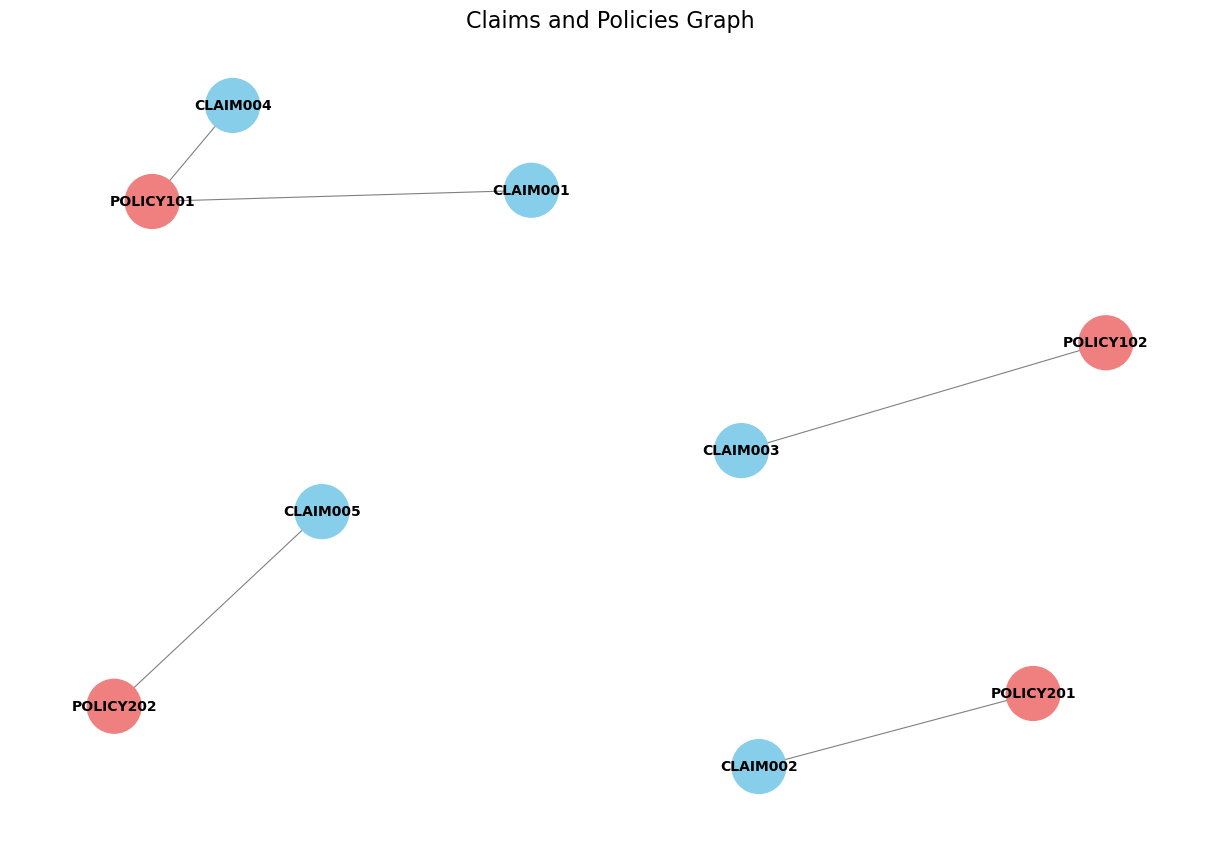

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Load your data using pandas
data = pd.read_csv('sample_data_graph.csv')

# 2. Create a NetworkX Graph
graph = nx.Graph()

# 3. Add Nodes (Claims and Policies)
# Let's add ClaimIDs and PolicyIDs as nodes
claims_nodes = data['ClaimID'].unique().tolist()
policy_nodes = data['PolicyID'].unique().tolist()

graph.add_nodes_from(claims_nodes, node_type='claim')  # Adding claim nodes with an attribute 'node_type'
graph.add_nodes_from(policy_nodes, node_type='policy')  # Adding policy nodes with attribute 'node_type'

# 4. Add Edges (Relationships - "Claim associated with Policy")
# Iterate through each row in your data and add edges
for index, row in data.iterrows():
    claim_id = row['ClaimID']
    policy_id = row['PolicyID']
    graph.add_edge(claim_id, policy_id, relationship='associated_with') # Adding an edge with an attribute 'relationship'

# 5. Visualize the Graph using matplotlib
plt.figure(figsize=(12, 8)) # Adjust figure size as needed

# Node colors based on node_type attribute
node_colors = ['skyblue' if data['node_type'] == 'claim' else 'lightcoral' for node, data in graph.nodes(data=True)]
pos = nx.spring_layout(graph, k=0.5, iterations=20) # Layout algorithm for better visualization, adjust parameters as needed
nx.draw(graph, pos, with_labels=True, node_color=node_colors, node_size=1500, font_size=10, font_weight='bold', edge_color='gray', width=0.8)

plt.title("Claims and Policies Graph", fontsize=16)
plt.show()

Making it interactive

In [2]:
import pandas as pd
import networkx as nx
import plotly.graph_objects as go

# 1. Load data (same as before)
data = pd.read_csv('sample_data_graph.csv')

# 2. Create NetworkX Graph (same as before)
graph = nx.Graph()
claims_nodes = data['ClaimID'].unique().tolist()
policy_nodes = data['PolicyID'].unique().tolist()
graph.add_nodes_from(claims_nodes, node_type='claim')
graph.add_nodes_from(policy_nodes, node_type='policy')
for index, row in data.iterrows():
    claim_id = row['ClaimID']
    policy_id = row['PolicyID']
    graph.add_edge(claim_id, policy_id, relationship='associated_with')

# 3. Prepare for Plotly Visualization
pos = nx.spring_layout(graph, k=0.5, iterations=20) # Get layout positions

edge_x = []
edge_y = []
for edge in graph.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None]) # None to break lines between edges
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.8, color='gray'),
    hoverinfo='none',
    mode='lines')

node_x = []
node_y = []
node_text = [] # For hover information
node_color = []
for node in graph.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node) # Display ClaimID or PolicyID on hover
    if graph.nodes[node]['node_type'] == 'claim':
        node_color.append('skyblue')
    else:
        node_color.append('lightcoral')

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=list(graph.nodes()), # Labels next to nodes (optional)
    textposition="bottom center", # Position of labels
    hoverinfo="text",
    hovertext=node_text,
    marker=dict(
        showscale=False,
        size=20,
        color=node_color,
        line_width=0.8))

# 4. Create Plotly Figure
fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title='Claims and Policies Graph (Interactive)',
                font_size=12,
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20,l=5,r=5,t=40),
                annotations=[ dict(
                    text="Claim-Policy Relationships",
                    showarrow=False,
                    xref="paper", yref="paper",
                    x=0.005, y=-0.002 ) ],
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )
fig.show()

Let's load some real claims data and see what we can do

In [14]:
cl["Loss Description"].value_counts()

Loss Description
COVID BI                                                  332
Theft                                                     171
Liability - Public Liability - Injury                     129
Escape of Water                                           116
Accidental Damage                                         112
                                                         ... 
Flood - River                                               1
Flood - Ground water Flood                                  1
Accidental Loss - Accidental Loss - Away From Premises      1
Business Interruption - Documents                           1
Business Interruption - Suppliers                           1
Name: count, Length: 150, dtype: int64

In [17]:
cl = pd.read_csv(r"C:\Users\TristramArmour\OneDrive - Innovisk\Documents\BU\Aqueous\aqpc_claims_network_data.csv")
# get rid of covid

cl = cl[cl["Loss Description"]!="COVID BI "].copy()

In [19]:
import pandas as pd
import networkx as nx
import plotly.graph_objects as go

# 1. Load your data
data = cl[cl.season_of_loss=="Winter"]

# 2. Create a NetworkX Graph
graph = nx.Graph()

# 3. Add Nodes (Claims, Policies, Locations, Claim Types)
claims_nodes = data['Claim Number'].unique().tolist()
policy_nodes = data['Policy Number'].unique().tolist()
location_nodes = data['postcode_area'].unique().tolist() # New: Location nodes
claim_type_nodes = data['Loss Description'].unique().tolist()   # New: Claim Type nodes
season_of_loss_nodes = data['season_of_loss'].unique().tolist()

graph.add_nodes_from(claims_nodes, node_type='claim')
graph.add_nodes_from(policy_nodes, node_type='policy')
graph.add_nodes_from(location_nodes, node_type='location')   # Add location nodes with type
graph.add_nodes_from(claim_type_nodes, node_type='claim_type') # Add claim type nodes with type
graph.add_nodes_from(season_of_loss_nodes,node_type='time_of_loss')


# 4. Add Edges (Relationships)
for index, row in data.iterrows():
    claim_id = row['Claim Number']
    policy_id = row['Policy Number']
    location = row['postcode_area']      # Get location from row
    claim_type = row['Loss Description']        # Get claim type from row
    season = row['season_of_loss']

    graph.add_edge(claim_id, policy_id, relationship='associated_with_policy') # Existing edge
    graph.add_edge(claim_id, location, relationship='occurred_at')          # New: Claim to Location edge
    graph.add_edge(claim_id, claim_type, relationship='is_type')            # New: Claim to Claim Type edge
    graph.add_edge(claim_id, season, relationship='occured_when') 


# 5. Visualize the Graph using Plotly (with different colors for new node types)
#pos = nx.spring_layout(graph, k=0.5, iterations=20)
pos = nx.kamada_kawai_layout(graph)

edge_x = []
edge_y = []
for edge in graph.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='lightgray'), # Thinner and lighter edges
    hoverinfo='none',
    mode='lines')

node_x = []
node_y = []
node_text = []
node_color = []
node_size = [] # You can also vary node size if needed

for node in graph.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)
    node_type = graph.nodes[node]['node_type'] # Get node type attribute
    if node_type == 'claim':
        node_color.append('skyblue')
        node_size.append(18) # Slightly smaller claim nodes
    elif node_type == 'policy':
        node_color.append('lightcoral')
        node_size.append(20)
    elif node_type == 'location':
        node_color.append('lightgreen')      # New color for location nodes
        node_size.append(15)                 # Smaller location nodes
    elif node_type == 'claim_type':
        node_color.append('gold')            # New color for claim type nodes
        node_size.append(15)                 # Smaller claim type nodes
    else:
        node_color.append('gray') # Default color just in case
        node_size.append(10)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=list(graph.nodes()), # Labels next to nodes
    textposition="bottom center",
    hoverinfo="text",
    hovertext=node_text,
    marker=dict(
        showscale=False,
        size=node_size, # Use varying node sizes
        color=node_color,
        line_width=0.8))

# 6. Analysis: Degree Centrality for Location Nodes
degree_centrality = nx.degree_centrality(graph) # Calculate degree centrality for all nodes

location_centrality_values = {}
for node in graph.nodes():
    if graph.nodes[node]['node_type'] == 'location':
        location_centrality_values[node] = degree_centrality[node]

claim_type_centrality_values = {}
for node in graph.nodes():
    if graph.nodes[node]['node_type'] == 'claim_type':
        claim_type_centrality_values[node] = degree_centrality[node]

time_of_loss_centrality_values = {}
for node in graph.nodes():
    if graph.nodes[node]['node_type'] == 'time_of_loss':
        time_of_loss_centrality_values[node] = degree_centrality[node]


# Sort locations by degree centrality in descending order
sorted_locations_by_centrality = sorted(location_centrality_values.items(), key=lambda item: item[1], reverse=True)
sorted_ct_by_centrality = sorted(claim_type_centrality_values.items(), key=lambda item: item[1], reverse=True)
sorted_season_by_centrality = sorted(time_of_loss_centrality_values.items(), key=lambda item: item[1], reverse=True)

print("\nLocation Degree Centrality (Top Locations associated with most claims):")
for location, centrality in sorted_locations_by_centrality:
    print(f"Location: {location}, Degree Centrality: {centrality:.4f}") # Print formatted centrality

print("\Claim Type Degree Centrality (Top claim types associated with most claims):")
for ct, centrality in sorted_ct_by_centrality:
    print(f"Claim type: {ct}, Degree Centrality: {centrality:.4f}") # Print formatted centrality

print("\Time of Loss Degree Centrality (Top time of loss associated with most claims):")
for season, centrality in sorted_season_by_centrality:
    print(f"Time of loss: {season}, Degree Centrality: {centrality:.4f}") # Print formatted centrality


# 7. Create Plotly Figure
fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title='Claims, Policies, Locations, and Claim Types Graph (Interactive)',
                font_size=10,
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20,l=5,r=5,t=40),
                annotations=[ dict(
                    text="Claim Relationships with Policies, Locations, and Claim Types",
                    showarrow=False,
                    xref="paper", yref="paper",
                    x=0.005, y=-0.002 ) ],
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title=''), # Removed axis titles and grid
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title='')) # Removed axis titles and grid
                )
fig.show()


Location Degree Centrality (Top Locations associated with most claims):
Location: NE, Degree Centrality: 0.0147
Location: M, Degree Centrality: 0.0147
Location: YO, Degree Centrality: 0.0098
Location: PL, Degree Centrality: 0.0090
Location: SA, Degree Centrality: 0.0090
Location: B, Degree Centrality: 0.0090
Location: SW, Degree Centrality: 0.0082
Location: WV, Degree Centrality: 0.0082
Location: E, Degree Centrality: 0.0074
Location: TN, Degree Centrality: 0.0074
Location: WF, Degree Centrality: 0.0074
Location: L, Degree Centrality: 0.0074
Location: SG, Degree Centrality: 0.0074
Location: OX, Degree Centrality: 0.0074
Location: BS, Degree Centrality: 0.0066
Location: CO, Degree Centrality: 0.0066
Location: SE, Degree Centrality: 0.0066
Location: SO, Degree Centrality: 0.0066
Location: CA, Degree Centrality: 0.0066
Location: LS, Degree Centrality: 0.0057
Location: LL, Degree Centrality: 0.0057
Location: G, Degree Centrality: 0.0057
Location: EX, Degree Centrality: 0.0057
Location: HU